In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spotify_top_1000_tracks.csv to spotify_top_1000_tracks.csv


In [ ]:
import pandas as pd

df = pd.read_csv('spotify_top_1000_tracks.csv', encoding="utf-8")

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

print("Dataset loaded and preprocessing complete!")
print(df.head(3))

Dataset loaded and preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [ ]:
import numpy as np

df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

df['year'] = df['year'].fillna(0).astype(int)

cols_to_drop = ['spotify_url', 'id']

if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')
if 'key' in df.columns:
    cols_to_drop.append('key')
if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
    print("tempo_category created")
else:
    print("tempo column not found")

df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("Data cleaning complete")
print("Final rows:", len(df))

tempo column not found
Data cleaning complete
Final rows: 971


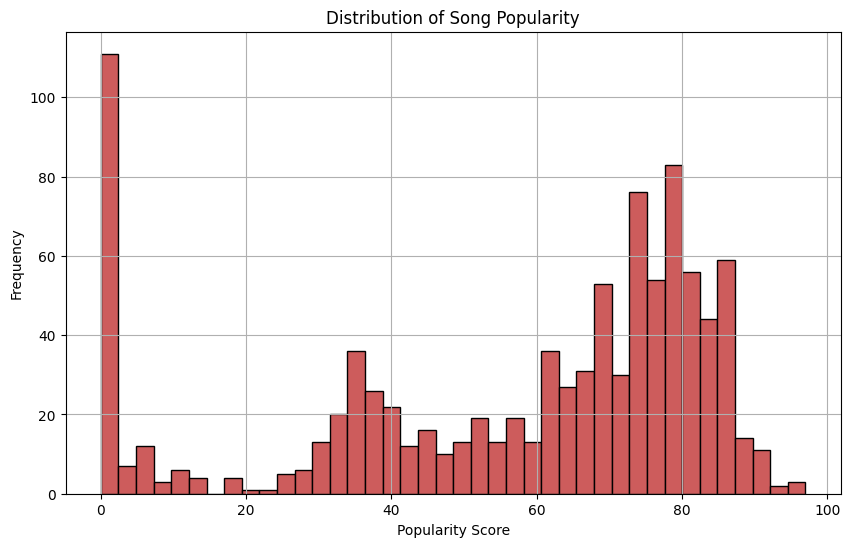

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='black')

plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

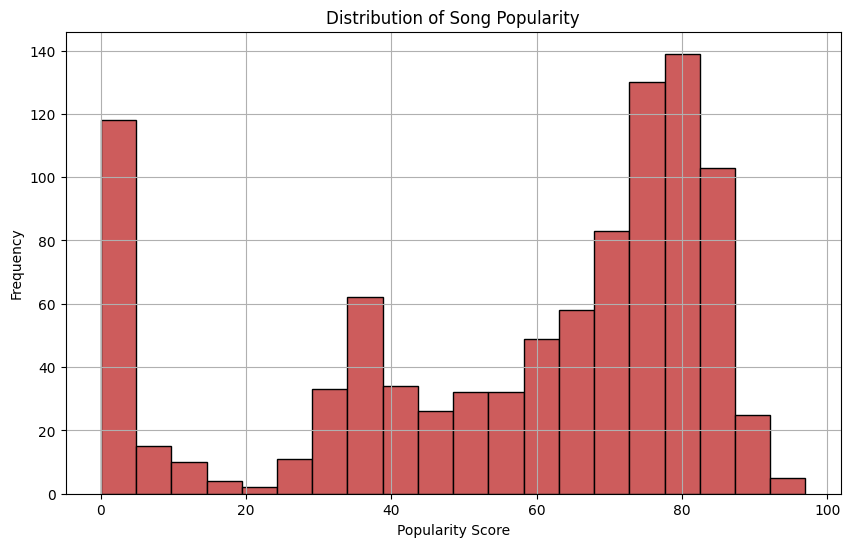

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=20, color='indianred', edgecolor='black')

plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

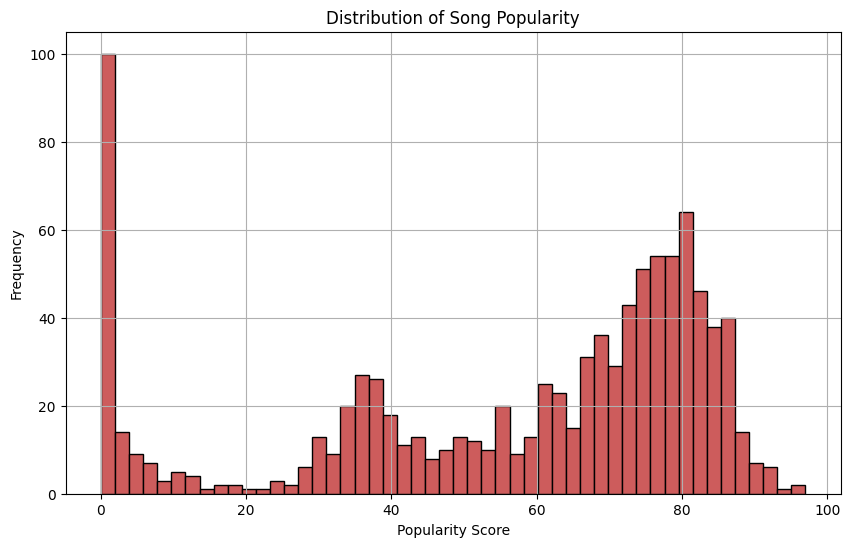

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=50, color='indianred', edgecolor='black')

plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

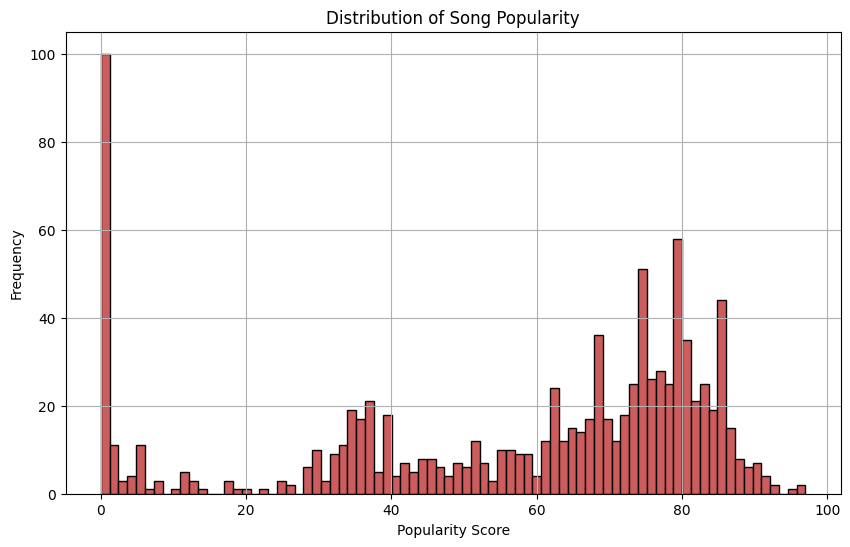

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=80, color='indianred', edgecolor='black')

plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

/tmp/ipykernel_10921/1353168869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


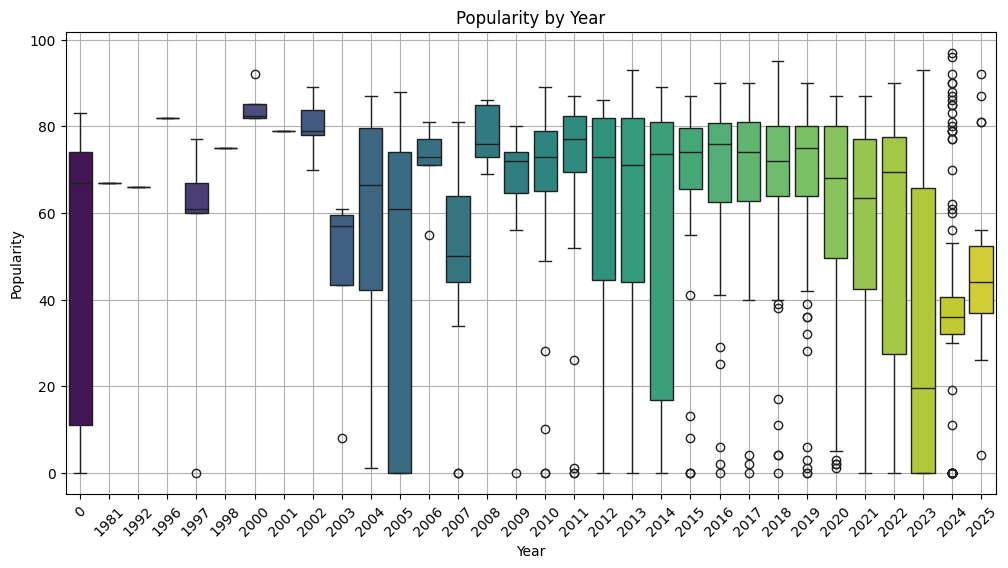

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')

plt.title('Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Popularity')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

/tmp/ipykernel_10921/1146338550.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


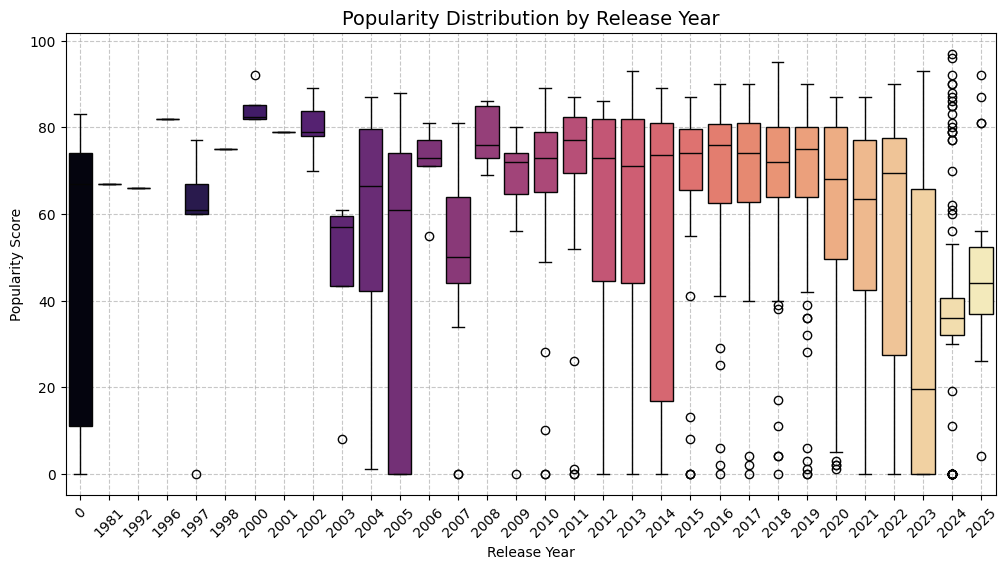

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='year',
    y='popularity',
    data=df,
    palette='magma'
)

plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

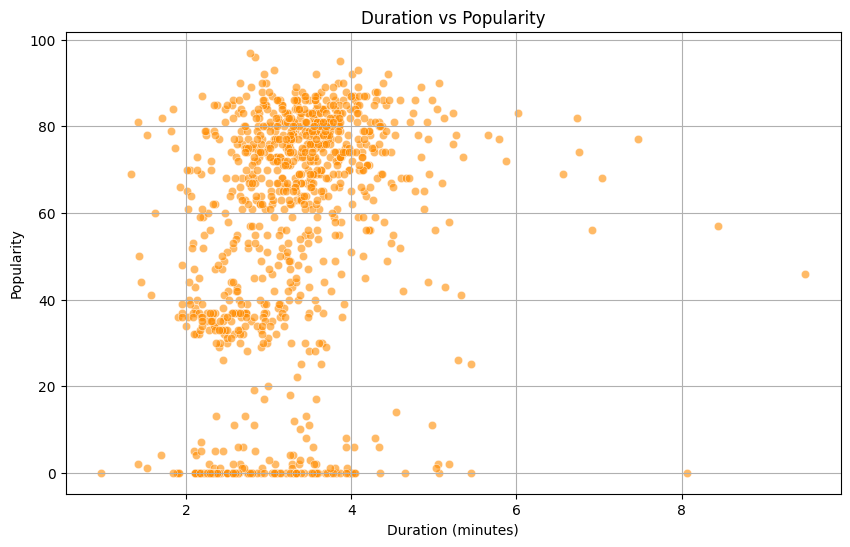

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df,
    alpha=0.6,
    color='darkorange'
)

plt.title('Duration vs Popularity')
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity')
plt.grid(True)
plt.show()

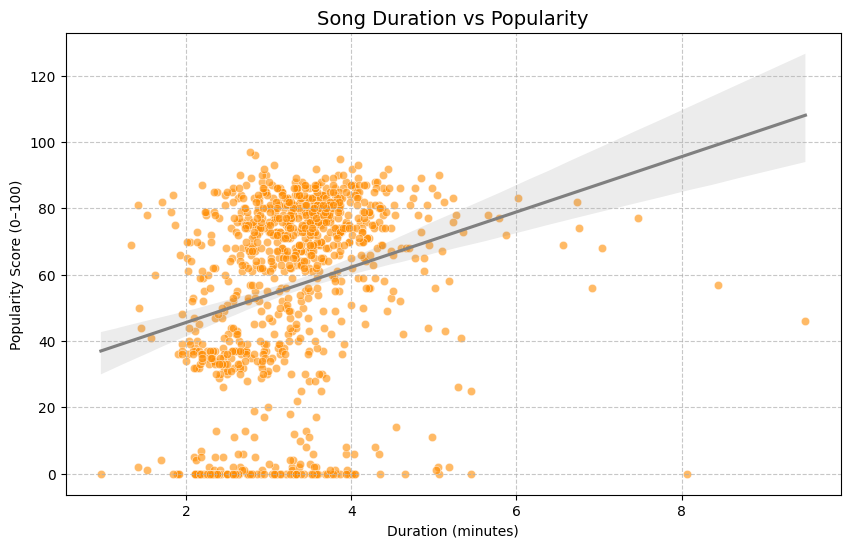

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df,
    alpha=0.6,
    color='darkorange'
)

sns.regplot(
    x='duration_min',
    y='popularity',
    data=df,
    scatter=False,
    color='grey'
)

plt.title('Song Duration vs Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0–100)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

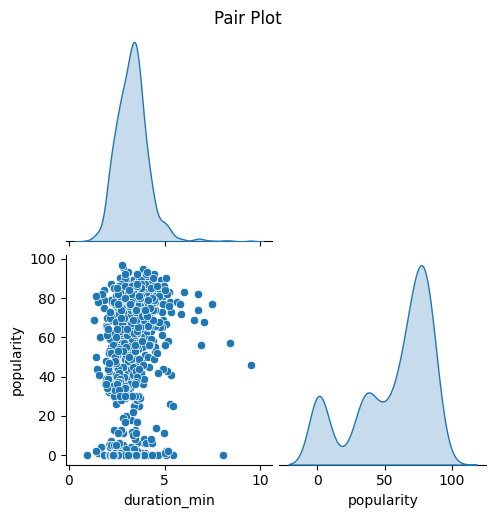

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['duration_min', 'popularity']

sns.pairplot(df[features], diag_kind='kde', corner=True)
plt.suptitle("Pair Plot", y=1.02)
plt.show()

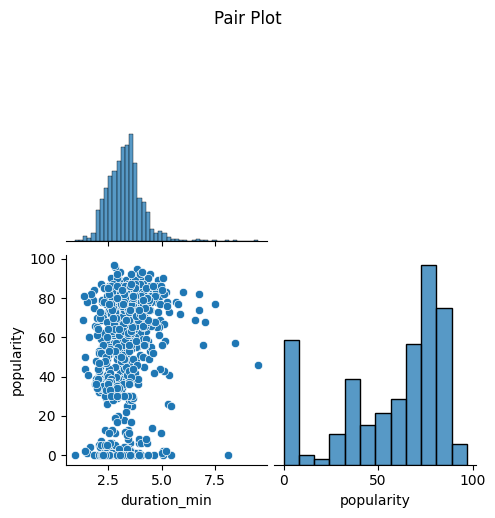

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['duration_min', 'popularity']

sns.pairplot(df[features], diag_kind='hist', corner=True)
plt.suptitle("Pair Plot", y=1.02)
plt.show()

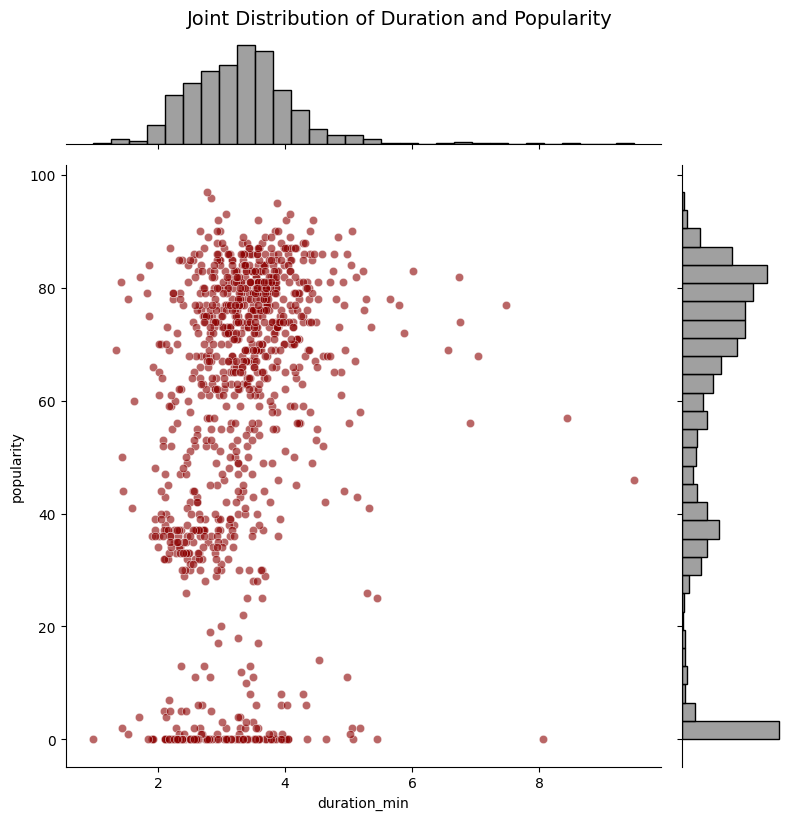

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',  # try 'kde' or 'reg' too
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)

plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)
plt.show()

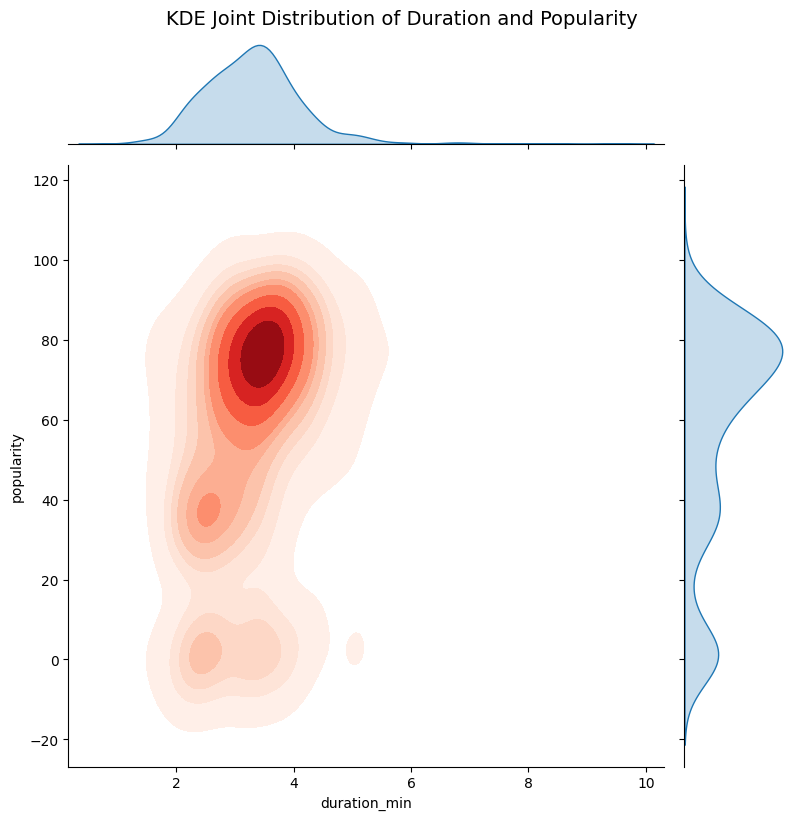

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='kde',
    height=8,
    fill=True,
    cmap='Reds'
)

plt.suptitle('KDE Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)
plt.show()

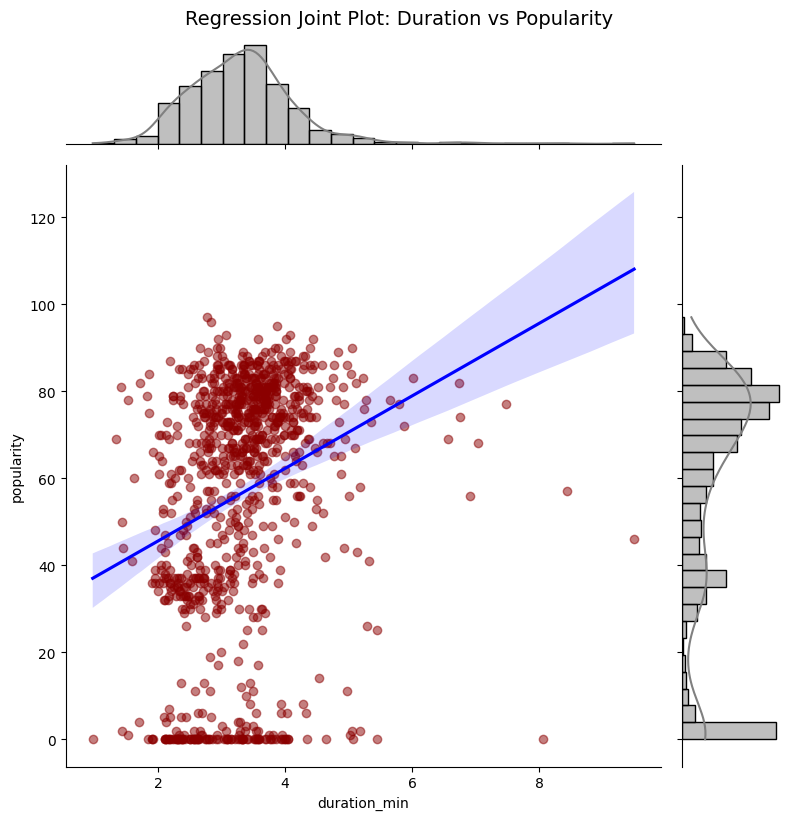

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg',
    height=8,
    scatter_kws={'alpha': 0.5, 'color': 'darkred'},
    line_kws={'color': 'blue'},
    marginal_kws={'bins': 25, 'color': 'gray', 'edgecolor': 'black'}
)

plt.suptitle('Regression Joint Plot: Duration vs Popularity', y=1.02, fontsize=14)
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)

line, = ax.plot([], [], color='blue')

def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100)

gif_path = os.path.abspath("popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))

print("GIF saved at:", gif_path)
webbrowser.open("file://" + gif_path)

plt.close(fig)

GIF saved at: /content/popularity_trend.gif
